In [6]:
import os
from pathlib import Path
import sys  

ROOT_DIR = Path().resolve().parents[1]
sys.path.append(str(ROOT_DIR))

# Local application imports
from config.paths import LSTM_RESULTS_FILE, XGBOOST_RESULTS_FILE ,SARIMAX_RESULTS_FILE

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:

lstm = pd.read_csv(LSTM_RESULTS_FILE)
xgb = pd.read_csv(XGBOOST_RESULTS_FILE)
sarimax = pd.read_csv(SARIMAX_RESULTS_FILE)

lstm["model"] = "LSTM"
xgb["model"] = "XGBoost"
sarimax["model"] = "SARIMAX"

df = pd.concat([lstm, xgb, sarimax], ignore_index=True)

In [8]:
summary = df.groupby("model").agg({
    "information_coefficient": ["mean", "std"],
    "spearman_ic": "mean",
    "rmse": "mean",
    "mae": "mean"
})

print(summary)

        information_coefficient           spearman_ic      rmse       mae
                           mean       std        mean      mean      mean
model                                                                    
LSTM                   0.057404  0.201905    0.044371  0.580533  0.480734
SARIMAX               -0.004360  0.197807   -0.009597  0.956439  0.836989
XGBoost                0.160675  0.170952    0.121041  0.522804  0.431466


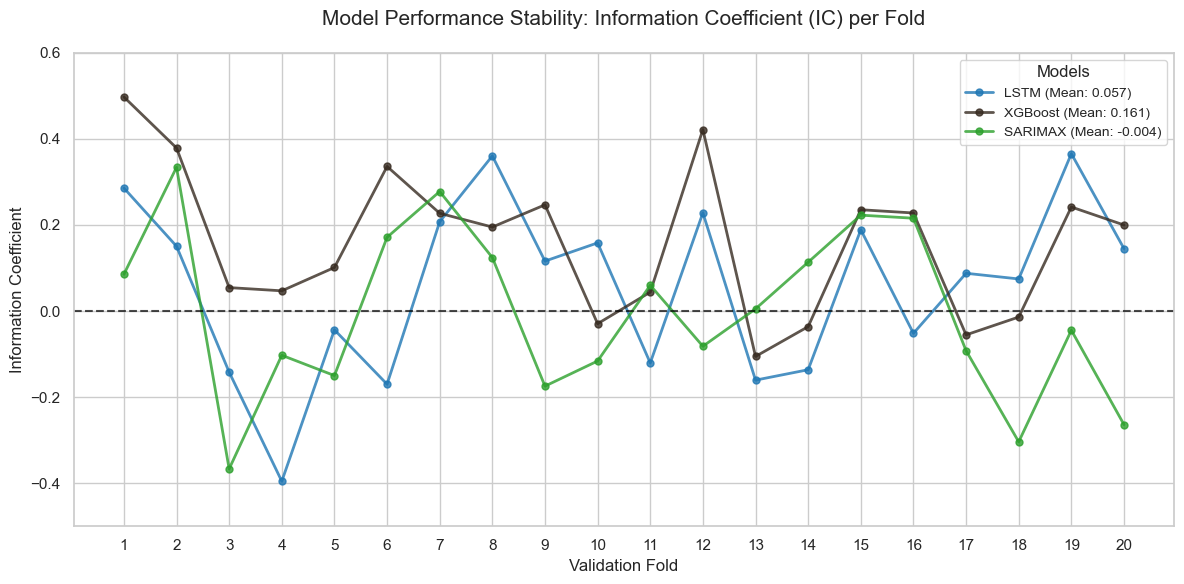

In [14]:
# Setting a clean aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Define a color palette for better distinction
colors = ["#1f77b4", "#362a20", "#2ca02c"]

for i, model in enumerate(df["model"].unique()):
    subset = df[df["model"] == model]
    
    # Calculate mean IC for the legend to add immediate context
    mean_ic = subset["information_coefficient"].mean()
    
    # Plot with markers to make individual data points visible
    plt.plot(
        subset["fold"], 
        subset["information_coefficient"], 
        label=f"{model} (Mean: {mean_ic:.3f})",
        marker='o', 
        markersize=5,
        linewidth=2,
        color=colors[i],
        alpha=0.8
    )

# Highlight the zero line (threshold for predictive power)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Formatting labels and title
plt.title("Model Performance Stability: Information Coefficient (IC) per Fold", fontsize=15, pad=20)
plt.xlabel("Validation Fold", fontsize=12)
plt.ylabel("Information Coefficient", fontsize=12)

# Adjusting axes for clarity
plt.xticks(df["fold"].unique()) # Ensure every fold number is shown
plt.ylim(-0.5, 0.6) # Add padding to the top and bottom

# Enhanced legend
plt.legend(title="Models", title_fontsize='12', fontsize='10', loc='best', frameon=True)

plt.tight_layout()
plt.show()

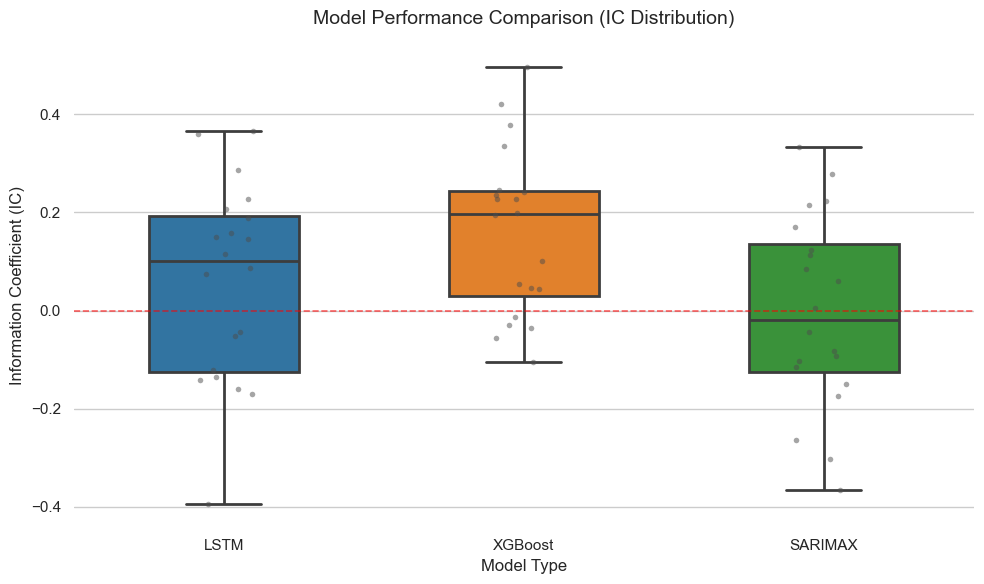

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Define colors
palette = {"LSTM": "#1f77b4", "SARIMAX": "#2ca02c", "XGBoost": "#ff7f0e"}

# 1. Fixed: Assign 'x' to 'hue' and set legend=False to remove the warning
ax = sns.boxplot(
    data=df, 
    x="model", 
    y="information_coefficient", 
    hue="model",          # Added hue
    palette=palette,
    legend=False,         # Added to hide redundant legend
    width=0.5,
    linewidth=2,
    fliersize=0 
)

# 2. Add individual points
sns.stripplot(
    data=df, 
    x="model", 
    y="information_coefficient", 
    color=".3", 
    size=4, 
    alpha=0.5
)

# 3. Add baseline
plt.axhline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.6)

# Formatting
plt.title("Model Performance Comparison (IC Distribution)", fontsize=14, pad=15)
plt.xlabel("Model Type", fontsize=12)
plt.ylabel("Information Coefficient (IC)", fontsize=12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [11]:
stability = df.groupby("model")["information_coefficient"].std()
print(stability)

model
LSTM       0.201905
SARIMAX    0.197807
XGBoost    0.170952
Name: information_coefficient, dtype: float64


In [12]:
df["positive_ic"] = df["information_coefficient"] > 0

positive_ratio = df.groupby("model")["positive_ic"].mean()
print(positive_ratio)

model
LSTM       0.60
SARIMAX    0.50
XGBoost    0.75
Name: positive_ic, dtype: float64


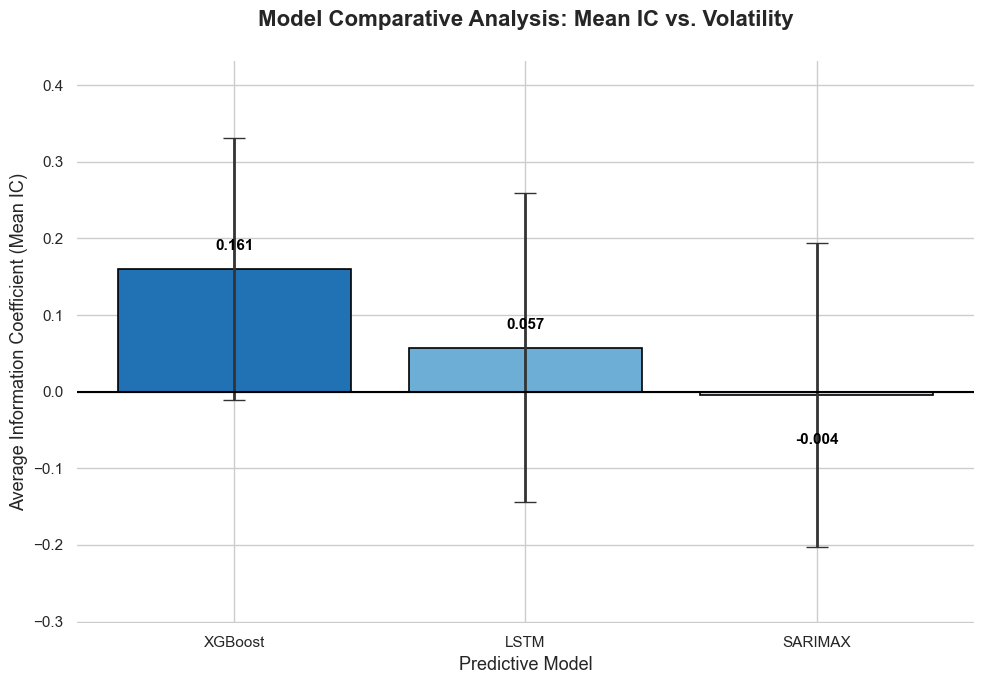

In [18]:
ic_mean = df.groupby("model")["information_coefficient"].mean().sort_values(ascending=False)
ic_std = df.groupby("model")["information_coefficient"].std().loc[ic_mean.index]

# Professional setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

# High-contrast color palette (Darker = Better Performance)
colors = sns.color_palette("Blues_r", len(ic_mean))

# 1. Create the Bar Plot
bars = plt.bar(
    ic_mean.index, 
    ic_mean.values, 
    yerr=ic_std.values, 
    capsize=8, 
    color=colors,
    edgecolor="black",
    linewidth=1.2,
    error_kw={'elinewidth': 2, 'ecolor': '#333333'} # High-visibility error bars
)

# 2. Add Mean Labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2., 
        height + 0.02 if height > 0 else height - 0.05,
        f'{height:.3f}',
        ha='center', 
        va='bottom' if height > 0 else 'top', 
        fontsize=11, 
        fontweight='bold',
        color='black'
    )

# 3. Enhance Baseline and Aesthetics
plt.axhline(0, color='black', linewidth=1.5) # Solid baseline
plt.title("Model Comparative Analysis: Mean IC vs. Volatility", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Average Information Coefficient (Mean IC)", fontsize=13)
plt.xlabel("Predictive Model", fontsize=13)

# Formatting Y-axis to show percentages or clearer decimals
plt.ylim(min(ic_mean.values - ic_std.values) - 0.1, max(ic_mean.values + ic_std.values) + 0.1)

# Remove unnecessary spines for a modern look
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

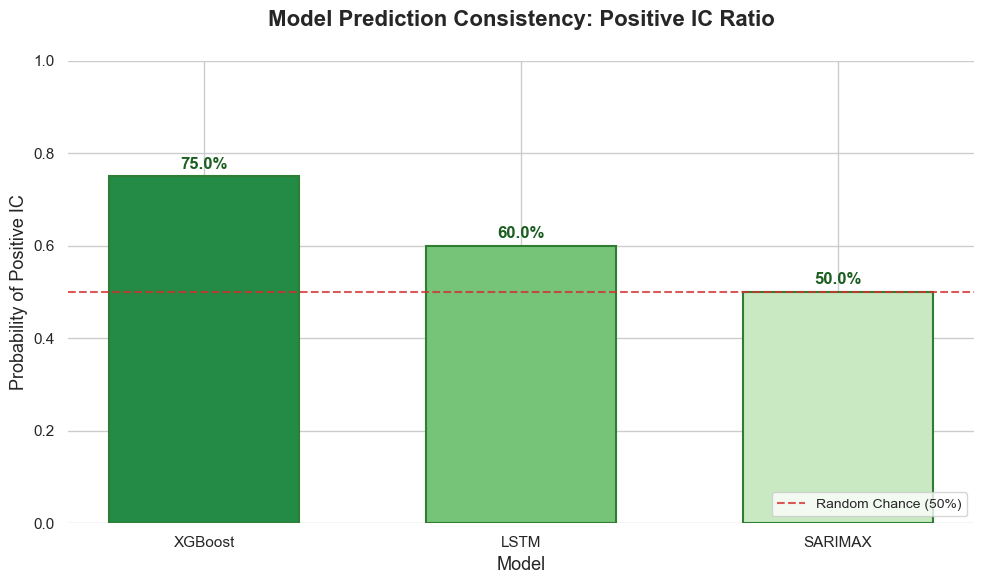

In [20]:

# Calculation for annotations and sorting
df["positive_ic"] = df["information_coefficient"] > 0
ratio = df.groupby("model")["positive_ic"].mean().sort_values(ascending=False)

# Professional setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Custom palette: Success-oriented colors (Green shades)
colors = sns.color_palette("Greens_r", len(ratio))

# 1. Create the Bar Plot
bars = plt.bar(
    ratio.index, 
    ratio.values, 
    color=colors,
    edgecolor="#2e7d32",
    linewidth=1.5,
    width=0.6
)

# 2. Add Percentage Labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2., 
        height + 0.01,
        f'{height*100:.1f}%', # Show as percentage
        ha='center', 
        va='bottom', 
        fontsize=12, 
        fontweight='bold',
        color='#1b5e20'
    )

# 3. Add a Reference Line at 50% (The "Coin Toss" threshold)
plt.axhline(0.5, color='#d32f2f', linestyle='--', linewidth=1.5, alpha=0.8, label="Random Chance (50%)")

# Formatting
plt.title("Model Prediction Consistency: Positive IC Ratio", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Probability of Positive IC", fontsize=13)
plt.xlabel("Model", fontsize=13)
plt.ylim(0, 1.0) # Scale from 0 to 100%

# Legend to explain the red line
plt.legend(loc='lower right', frameon=True, fontsize=10)

# Modern aesthetics
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()